[[0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]
 ...
 [0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]]
A      = 606.807 +/- 22.930
tau = 1.0888 +/- 0.0232


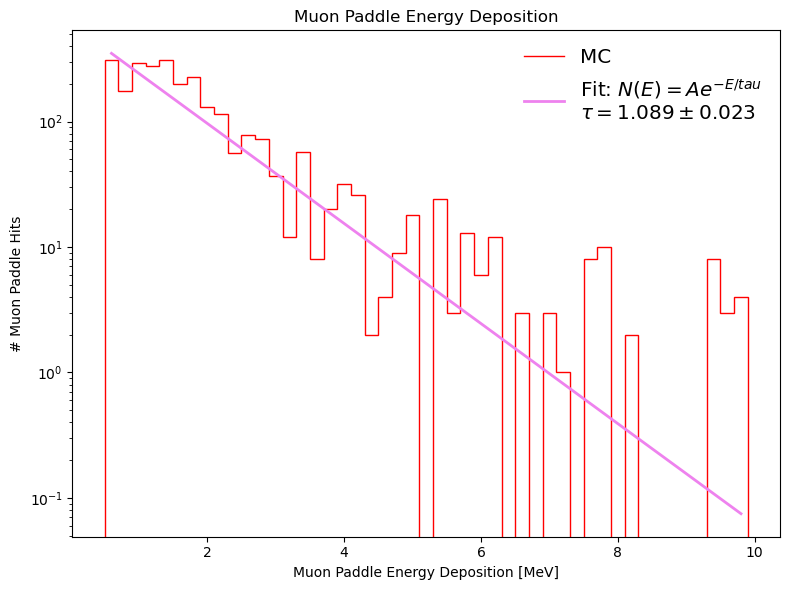

In [15]:
import ROOT
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

# ============================================================
# Reading the Data File
# ============================================================
output = ROOT.RDataFrame(
    "output",
    "/home/wto/Eos/EosSimulations/muonPaddle_CRY_Z2.5m_5kEvt_0.root"
)
# Extract muon paddle energy deposition
muonPaddleEdep_tuple = output.AsNumpy(
    columns=["muonPaddleEdep"]
)["muonPaddleEdep"]
# Some events have 0 lengths for muonPaddleEdep for some reason...
# Check with EosSimulations folks in the future.
# For now just keep those rows.
muonPaddleEdep = np.stack([
    row for row in muonPaddleEdep_tuple
    if len(row) != 0
])

print(muonPaddleEdep)

# ============================================================
# Histograming
# ============================================================

counts, bin_edges = np.histogram(
    muonPaddleEdep.flatten(),
    bins=np.arange(0.5, 10, 0.2)
)

bin_centers = 0.5 * (bin_edges[:-1] + bin_edges[1:])


# ============================================================
# Exponential fit
# N(E) = A * exp(-lambda * E)
# ============================================================

def exponential(x, A, tau):
    return A * np.exp(-x/tau)


# Only fit bins containing events
fit_mask = counts > 0

x_fit = bin_centers[fit_mask]
y_fit = counts[fit_mask]

# Poisson uncertainty on histogram counts
y_err = np.sqrt(y_fit)

popt, pcov = curve_fit(
    exponential,
    x_fit,
    y_fit,
    sigma=y_err,
    absolute_sigma=True,
    p0=[y_fit.max(), 1.0]
)

A_fit, tau_fit = popt

A_err, tau_err = np.sqrt(np.diag(pcov))

print(f"A      = {A_fit:.3f} +/- {A_err:.3f}")
print(f"tau = {tau_fit:.4f} +/- {tau_err:.4f}")

# Smooth curve for displaying fit
x_curve = np.linspace(
    x_fit.min(),
    x_fit.max(),
    500
)

y_curve = exponential(
    x_curve,
    A_fit,
    tau_fit
)


# ============================================================
# Plot
# ============================================================

plt.figure(figsize=(8,6))

plt.stairs(counts,bin_edges,color="red",label="MC")

plt.plot(
    x_curve,
    y_curve,
    linewidth=2,
    label=(
        r"Fit: $N(E)=A e^{-E/tau}$"
        "\n"
        rf"$\tau = {tau_fit:.3f} \pm {tau_err:.3f}$"
    )
)

plt.xlabel("Muon Paddle Energy Deposition [MeV]")
plt.ylabel("# Muon Paddle Hits")
plt.title("Muon Paddle Energy Deposition")

plt.yscale("log")

plt.legend()

plt.tight_layout()
plt.show()

In [16]:
muonPaddleXYZ = np.array([
    [695.658, 1365.306, -398.908],
    [681.278, 1337.084, 699.896],
    [473.512, 1457.321, -398.908],
    [-704.85, -549.402, 1972.377],
    [239.707, 1513.453, -398.908],
    [234.753, 1482.169, 699.896],
    [-273.05, -549.402, 1972.377],
    [-273.05, 549.402, 1940.704],
    [-239.707, 1513.453, -398.908],
    [-234.753, 1482.169, 699.896],
    [0.0, 0.0, 0.0],
    [0.0, 0.0, 0.0],
    [1270.0, 549.402, -1839.012],
    [549.402, 920.75, 2098.311],
    [549.402, 1136.65, 2098.311],
    [-488.95, -549.402, 1972.377],
    [0.0, 0.0, 0.0],
    [1016.0, 549.402, -1839.012],
    [762.0, 549.402, -1839.012],
    [508.0, 549.402, -1839.012],
    [254.0, 549.402, -1839.012],
    [0.0, 549.402, -1839.012],
    [239.707, -1513.453, -398.908],
    [0.0, -1532.319, -398.908],
    [-239.707, -1513.453, -398.908],
    [-473.512, -1457.321, -398.908],
    [-695.658, -1365.306, -398.908],
    [-1270.0, 549.402, -1839.012],
    [-1016.0, 549.402, -1839.012],
    [-762.0, 549.402, -1839.012],
    [-508.0, 549.402, -1839.012],
    [-254.0, 549.402, -1839.012],
    [473.512, -1457.321, -398.908],
    [695.658, -1365.306, -398.908],
    [900.674, -1239.672, -398.908],
    [1083.513, -1083.513, -398.908],
    [1513.453, -239.707, -398.908],
    [1457.321, -473.512, -398.908],
    [1365.306, -695.658, -398.908],
    [1239.672, -900.674, -398.908],
    [-920.75, 549.402, 1940.704],
    [1482.169, 234.753, 699.896],
    [273.05, 549.402, 1940.704],
    [488.95, 549.402, 1940.704],
    [704.85, -549.402, 1972.377],
    [704.85, 549.402, 1940.704],
    [488.95, -549.402, 1972.377],
    [1270.0, -549.402, -1807.338],
    [-549.402, 920.75, 2129.984],
    [-549.402, 1136.65, 2129.984],
    [-488.95, 549.402, 1940.704],
    [-704.85, 549.402, 1940.704],
    [1016.0, -549.402, -1807.338],
    [762.0, -549.402, -1807.338],
    [508.0, -549.402, -1807.338],
    [254.0, -549.402, -1807.338],
    [0.0, -549.402, -1807.338],
    [234.753, -1482.169, 699.896],
    [0.0, -1500.645, 699.896],
    [-234.753, -1482.169, 699.896],
    [-463.725, -1427.198, 699.896],
    [-681.278, -1337.084, 699.896],
    [-1270.0, -549.402, -1807.338],
    [-1016.0, -549.402, -1807.338],
    [-762.0, -549.402, -1807.338],
    [-508.0, -549.402, -1807.338],
    [-254.0, -549.402, -1807.338],
    [463.725, -1427.198, 699.896],
    [681.278, -1337.084, 699.896],
    [882.057, -1214.047, 699.896],
    [1061.116, -1061.116, 699.896],
    [1482.169, -234.753, 699.896],
    [1427.198, -463.725, 699.896],
    [1337.084, -681.278, 699.896],
    [1214.047, -882.057, 699.896],
    [1513.453, 239.707, -398.908],
    [0.0, 0.0, 0.0],
    [273.05, -549.402, 1972.377],
    [0.0, 0.0, 0.0],
    [920.75, -549.402, 1972.377],
    [920.75, 549.402, 1940.704],
    [0.0, 0.0, 0.0],
    [-1457.321, 473.512, -398.908],
    [-1513.453, 239.707, -398.908],
    [-1427.198, 463.725, 699.896],
    [-1482.169, 234.753, 699.896],
    [-1365.306, 695.658, -398.908],
    [-1532.319, 0.0, -398.908],
    [-1337.084, 681.278, 699.896],
    [-1500.645, 0.0, 699.896],
    [-900.674, -1239.672, -398.908],
    [-1513.453, -239.707, -398.908],
    [-882.057, -1214.047, 699.896],
    [-1482.169, -234.753, 699.896],
    [-1083.513, -1083.513, -398.908],
    [-473.512, 1457.321, -398.908],
    [-1061.116, -1061.116, 699.896],
    [-463.725, 1427.198, 699.896],
    [-1239.672, -900.674, -398.908],
    [-695.658, 1365.306, -398.908],
    [-1214.047, -882.057, 699.896],
    [-681.278, 1337.084, 699.896],
    [-1365.306, -695.658, -398.908],
    [-900.674, 1239.672, -398.908],
    [-1337.084, -681.278, 699.896],
    [-882.057, 1214.047, 699.896],
    [0.0, 0.0, 0.0],
    [0.0, 0.0, 0.0],
    [549.402, -1136.65, 2098.311],
    [-1239.672, 900.674, -398.908],
    [-549.402, -1136.65, 2129.984],
    [-1214.047, 882.057, 699.896],
    [549.402, -920.75, 2098.311],
    [-1083.513, 1083.513, -398.908],
    [-549.402, -920.75, 2129.984],
    [-1061.116, 1061.116, 699.896],
    [549.402, -704.85, 2098.311],
    [549.402, 704.85, 2098.311],
    [-549.402, -704.85, 2129.984],
    [-549.402, 704.85, 2129.984],
    [549.402, -488.95, 2098.311],
    [549.402, 488.95, 2098.311],
    [-549.402, -488.95, 2129.984],
    [-549.402, 488.95, 2129.984],
    [549.402, -273.05, 2098.311],
    [549.402, 273.05, 2098.311],
    [-549.402, -273.05, 2129.984],
    [-549.402, 273.05, 2129.984],
    [1136.65, -549.402, 1972.377],
    [-1457.321, -473.512, -398.908],
    [1136.65, 549.402, 1940.704],
    [-1427.198, -463.725, 699.896],
    [0.0, 0.0, 0.0],
    [0.0, 0.0, 0.0],
], dtype=float)

In [17]:
# Extract x, y, z from the 134 x 3 position array
x_pos = muonPaddleXYZ[:, 0]
y_pos = muonPaddleXYZ[:, 1]
z_pos = muonPaddleXYZ[:, 2]

# Assign layer number based on z position
layer = np.zeros(134, dtype=int)

layer[np.isclose(z_pos, 2129.984)] = 1  # TopUpper-x
layer[np.isclose(z_pos, 2098.311)] = 2  # TopUpper+x
layer[np.isclose(z_pos, 1972.377)] = 3  # TopLower-y
layer[np.isclose(z_pos, 1940.704)] = 4  # TopLower+y
layer[np.isclose(z_pos, 699.896)]  = 5  # Barrel+z
layer[np.isclose(z_pos, -398.908)] = 6  # Barrel-z
layer[np.isclose(z_pos, -1807.338)] = 7 # Bottom-y
layer[np.isclose(z_pos, -1839.012)] = 8 # Bottom+y

# Combine layer, position, and event-by-event energy deposition
muon_pos_hits = np.vstack([
    layer,
    x_pos,
    y_pos,
    z_pos,
    muonPaddleEdep
])

print(muon_pos_hits[0,:])

[6. 5. 6. 3. 6. 5. 3. 4. 6. 5. 0. 0. 8. 2. 2. 3. 0. 8. 8. 8. 8. 8. 6. 6.
 6. 6. 6. 8. 8. 8. 8. 8. 6. 6. 6. 6. 6. 6. 6. 6. 4. 5. 4. 4. 3. 4. 3. 7.
 1. 1. 4. 4. 7. 7. 7. 7. 7. 5. 5. 5. 5. 5. 7. 7. 7. 7. 7. 5. 5. 5. 5. 5.
 5. 5. 5. 6. 0. 3. 0. 3. 4. 0. 6. 6. 5. 5. 6. 6. 5. 5. 6. 6. 5. 5. 6. 6.
 5. 5. 6. 6. 5. 5. 6. 6. 5. 5. 0. 0. 2. 6. 1. 5. 2. 6. 1. 5. 2. 2. 1. 1.
 2. 2. 1. 1. 2. 2. 1. 1. 3. 6. 4. 5. 0. 0.]


In [23]:
############### Get a list of Events with only 1 TopUp, TopLow and Bottom hit.
# Get the Columns numbers for each layer.
TopUp = np.where((muon_pos_hits[0] == 1) | (muon_pos_hits[0] == 2))[0]
TopLow = np.where((muon_pos_hits[0] == 3) | (muon_pos_hits[0] == 4))[0]
Bottom = np.where((muon_pos_hits[0] == 7) | (muon_pos_hits[0] == 8))[0]
Barrel = np.where((muon_pos_hits[0] == 5) | (muon_pos_hits[0] == 6))[0]

# Count hits only in the selected columns of the layers
TopUpHits = np.count_nonzero(muon_pos_hits[4:, TopUp] > 0.1, axis=1)
TopLowHits = np.count_nonzero(muon_pos_hits[4:, TopLow] > 0.1, axis=1)
BottomHits = np.count_nonzero(muon_pos_hits[4:, Bottom] > 0.1, axis=1)
BarrelHits = np.count_nonzero(muon_pos_hits[4:, Barrel] > 0.1, axis=1)
event_list = []

for iEvt in range(4,len(muon_pos_hits[4:])):
    if TopUpHits[iEvt] >= 1 and TopLowHits[iEvt] >= 1 and BottomHits[iEvt] >= 1 and BarrelHits[iEvt] >= 0:
        event_list.append(iEvt)
print("len(event_list)=",len(event_list))


len(event_list)= 0


[  0.           0.           0.         ... 171.41113281   0.
   0.        ]


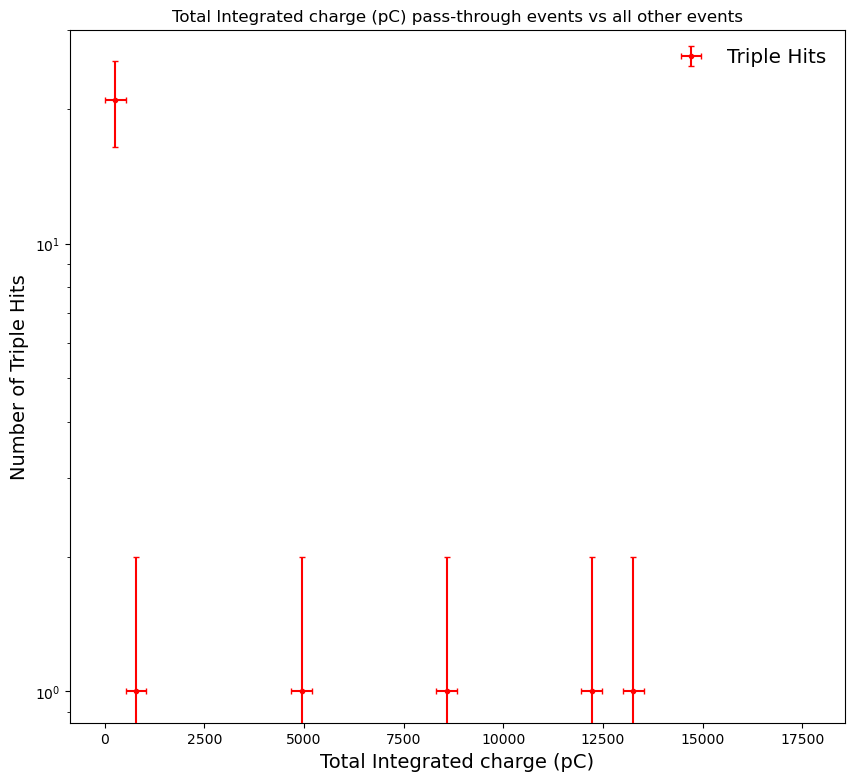

In [22]:
import ROOT
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit
from Eos import gaussian, apply_eos_plot_style

apply_eos_plot_style()
fig, ax = plt.subplots(figsize=(10, 9))
ax.set_title("Total Integrated charge (pC) pass-through events vs all other events")
ax.set_xlabel("Total Integrated charge (pC)", fontsize=14)
ax.set_ylabel("Number of Triple Hits", fontsize=14)
ax.set_yscale("log")

# Read charge array branch
digitCharge = output.AsNumpy(columns=["digitCharge"])["digitCharge"]


# Sum only charges above 0.5 in each event
digitTotalCharge = np.array([np.sum(np.asarray(charges)[np.asarray(charges) > 0.5]) 
    for charges in digitCharge],dtype=float)

event_list = np.array(event_list, dtype=int)

selected_charge = digitTotalCharge[event_list]

print(digitTotalCharge)
selected_counts, charge_bins = np.histogram(
    selected_charge,
    bins=np.arange(0, 18000, 520)
)

charge_bin_centers = 0.5 * (
    charge_bins[:-1] + charge_bins[1:]
)

ax.errorbar(
    charge_bin_centers,
    selected_counts,
    yerr=np.sqrt(selected_counts),
    xerr=260,
    color="red",
    marker=".",
    linestyle="",
    capsize=2,
    label=f"Triple Hits", # ({len(selected_events)} events)",
    zorder=3
)

ax.legend(framealpha=0)
plt.show()